# Hierarchical Clustering

## What is hierarchical clustering?

Hierarchical clustering is an unsupervised learning method that builds a multilevel *tree* (or a <span style="color:#1f77b4">**dendrogram**</span>) showing how observations group together from clusters with a single observation all the way up to one giant cluster that contains all observations.

The idea is simple: reveal <span style="color:#2ca02c">**nested structure**</span> by successively <span style="color:#ff7f0e">**merging**</span> (or <span style="color:#ff7f0e">**splitting**</span>) clusters based solely on pair-wise dissimilarity or similarity measures, without pre-specifying the number of clusters $k$.

---

### How It Works

| Direction     | Nickname        | Conceptual algorithm                                                                                                     |
| ------------- | --------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Bottom-up | <span style="color:#1f77b4">**Agglomerative**</span> | 1. Start with every point in its own cluster.<br>2. <span style="color:#2ca02c">**Find the closest pair**</span> of clusters using a linkage rule.<br>3. Merge them; record the distance in the dendrogram.<br>4. Update the distance matrix; repeat until only one cluster remains. |
| Top-down  | Divisive      | 1. Start with all points in one big cluster.<br>2. <span style="color:#ff7f0e">**Split**</span> the cluster that contributes most to overall dissimilarity.<br>3. Re-evaluate which cluster to split next; stop at desired granularity.               |

Linkage rules for agglomerative:

* Single: distance between nearest members
* Complete: distance between farthest members
* Average: average pairwise distance
* Ward: increase in within-cluster SSE (variance-minimizing)

---

### Pros and Cons

✅ Only requires a distance or similarity matrix (and a linkage rule).  
✅ Produces an "interpretable" dendrogram that maintains a hierarchical structure.  
✅ No requirement to choose $k$ in advance; you can “cut” the tree later based on domain knowledge.    

❌ High computational cost: quadratic memory & time for naïve agglomerative algorithms.  
❌ Greedy merges always chooses what seems best right now, not what might be best in the long run.   
❌ Sensitive to outliers (depending on the linkage rules and measures).   

---

### Key Hyper-parameters (Hierarchical Clustering in `scipy`)

| Parameter in `scipy`        | Meaning                                            | Typical choices / notes                                                              |
| --------------------------- | -------------------------------------------------- | ------------------------------------------------------------------------------------ |
| `method` (in `linkage`)     | How to measure inter-cluster distance              | `"ward"` (numerical only), `"complete"`, `"average"`, `"single"`                     |
| `metric` (in `pdist`)       | Distance metric used to compute pairwise distances | `"euclidean"`, `"cityblock"`, `"cosine"`, etc.                                       |
| `t` (in `fcluster`)         | Threshold for cutting dendrogram                   | A number (e.g. height or number of clusters depending on `criterion`)                |
| `criterion` (in `fcluster`) | How to interpret `t`                               | `"maxclust"` (number of clusters), `"distance"` (cut height), `"inconsistent"`, etc. |

> Note: You can also use the `AgglomerativeClustering` function from `sklearn.cluster`, but `sklearn.cluster` does not contain functions for generating the dendrogram.

---

> *A dendrogram is a family tree for your data: every merge marries the two closest clusters, the linkage rule decides what "closest" means, and where you cut the trunk decides how many families you see.* --- Words of wisdom by Claude Fable 5 (2026)


### Example with the Palmer Penguin data

We will use the [palmer penguin data](https://allisonhorst.github.io/palmerpenguins/articles/intro.html#meet-the-penguins) to illustrate hierarchical clustering. 

### Penguin species in the Palmer dataset

<table>
  <tr>
    <td style="text-align:center; vertical-align:top; width:33%;">
      <img src="../../figures/Adelie-penguin.webp" alt="Adelie penguin" style="width:95%; max-height:260px; object-fit:contain;"><br>
      <strong>Adelie penguin</strong><br>
      Source: <a href="https://www.britannica.com/animal/Adelie-penguin">Encyclopaedia Britannica</a>
    </td>
    <td style="text-align:center; vertical-align:top; width:33%;">
      <img src="../../figures/Chinstrap-penguin.webp" alt="Chinstrap penguin" style="width:95%; max-height:260px; object-fit:contain;"><br>
      <strong>Chinstrap penguin</strong><br>
      Source: <a href="https://www.britannica.com/animal/chinstrap-penguin">Encyclopaedia Britannica</a>
    </td>
    <td style="text-align:center; vertical-align:top; width:33%;">
      <img src="../../figures/Gentoo-penguin.webp" alt="Gentoo penguin" style="width:95%; max-height:260px; object-fit:contain;"><br>
      <strong>Gentoo penguin</strong><br>
      Source: <a href="https://www.britannica.com/animal/gentoo-penguin">Encyclopaedia Britannica</a>
    </td>
  </tr>
</table>


Note: Check out the penguins on Britannica if they fail to show in your notebook

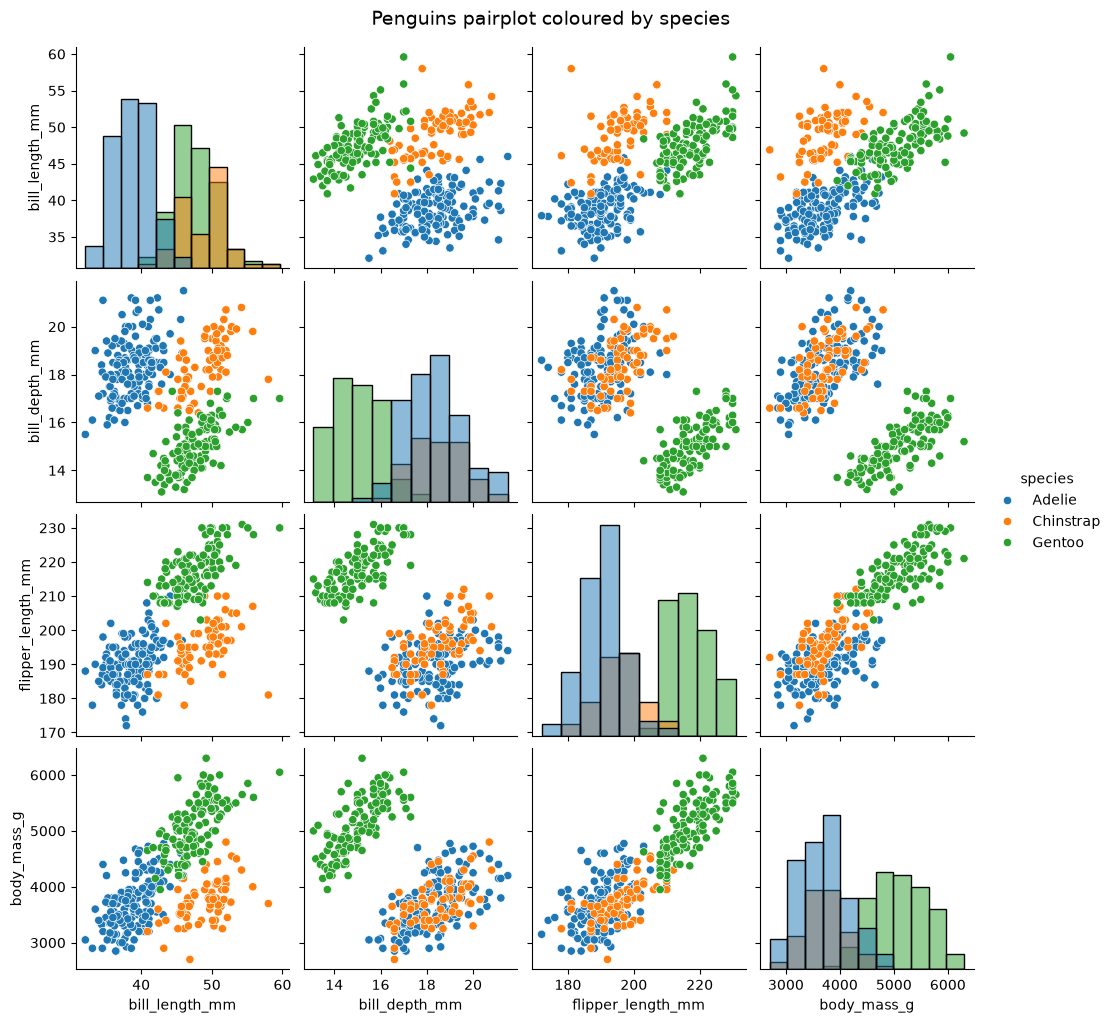

In [1]:
# --- Look at the data before clustering anything -------------------------
# (Clustering is unsupervised: the species column is held out as the
#  "truth" we will compare against, never given to the algorithm.)
import seaborn as sns
import matplotlib.pyplot as plt
# Load the Palmer penguins dataset
penguins = sns.load_dataset("penguins").dropna()

# Select the four numeric variables to include
numeric_vars = ["bill_length_mm", "bill_depth_mm",
                "flipper_length_mm", "body_mass_g"]

# Create the pairplot, colouring by species
sns.pairplot(
    data=penguins,
    vars=numeric_vars,
    hue="species",
    diag_kind="hist",       # or 'kde'
    corner=False            # show upper-triangle too; set True if you prefer half
)

plt.suptitle("Penguins pairplot coloured by species", y=1.02, fontsize=14)
plt.show()


In [2]:
# Prepare data for clustering

import seaborn as sns
import pandas as pd

# Load penguin dataset
penguins = sns.load_dataset("penguins")

# Drop rows with missing values
penguins = penguins.dropna()

# Use numeric features for clustering
# (these four columns define the space in which pairwise distances --
#  the only input the algorithm needs -- will be computed)
features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
X = penguins[features]


Try the following code to 
- fit a hierarchical clustering on the penguin data
- draw the corresponding dendrogram 
- visualize the clustering results with true labels.

You can play around with code to investigate the properties of hiearchical clustering. 

In [3]:
# Hierarchical clustering using SciPy
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, fcluster

# Standardize features
# (distances drive every merge in Steps 2-4; unscaled, body_mass_g in grams
#  would dominate all other features)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Try without scaling as well
# X_scaled = X

# Perform hierarchical clustering using SciPy
# linkage() runs the whole agglomerative algorithm from 'How It Works':
#   Step 1: every penguin starts as its own cluster
#   Step 2: find the closest pair of clusters under the LINKAGE rule
#           (method="ward" = merge the pair that least inflates within-cluster SSE)
#   Step 3: merge them; record the merge height in Z
#   Step 4: update the distance matrix; repeat until one cluster remains
# Z is the full merge history -- exactly what the dendrogram will draw.
Z = linkage(X_scaled, method="ward")  # Try 'average', 'complete', etc.

# Get cluster labels for a fixed number of clusters (e.g., 3)
# fcluster() CUTS the tree built above: criterion='maxclust' with t=3 picks
# the cut height that leaves exactly 3 clusters. (Only now is k chosen --
# after the tree is built, not before.)
cluster_labels = fcluster(Z, t=3, criterion='maxclust')

# Add to your DataFrame
penguins["cluster"] = cluster_labels

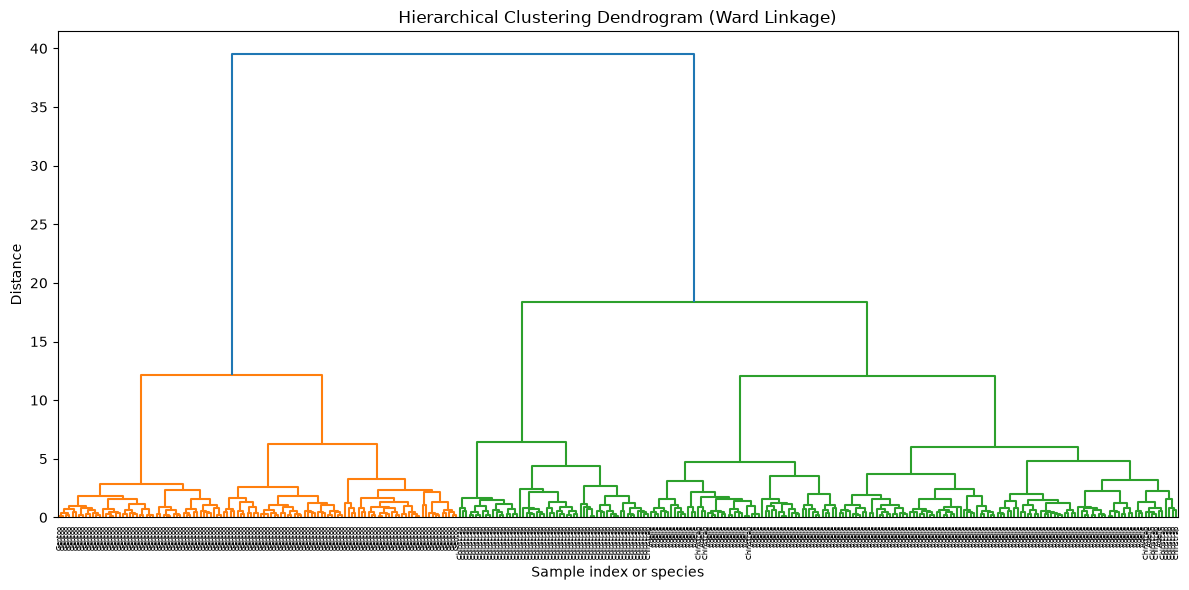

In [4]:
from scipy.cluster.hierarchy import  dendrogram
# Plot dendrogram: the record of Steps 1-4. Each U-join is one Step-3 merge;
# its height is the inter-cluster distance at which the merge happened.
# A horizontal cut at height h yields the clusters present at that distance.
plt.figure(figsize=(12, 6))
dendrogram(Z, labels=penguins["species"].values, leaf_rotation=90)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Sample index or species")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

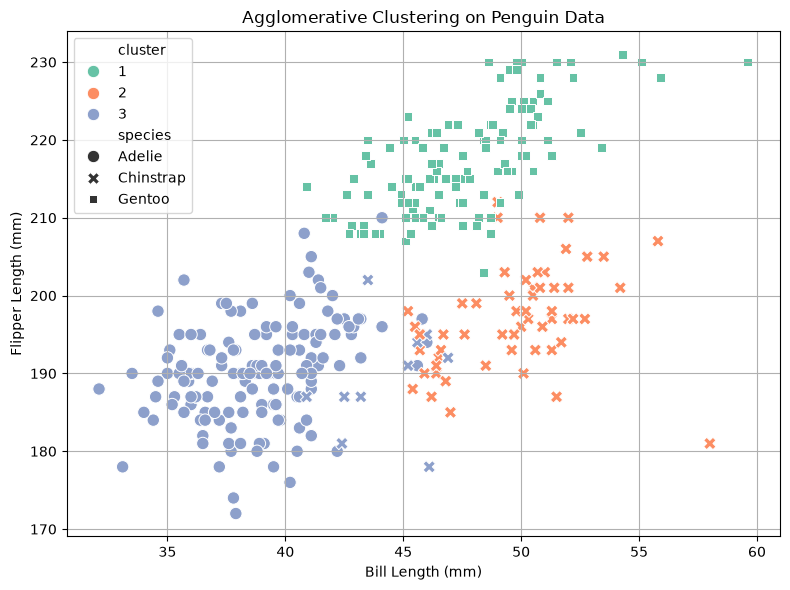

In [5]:

# Visualize the clusters using features of your choice
# color = cluster found by the algorithm (from the k=3 cut above);
# marker = true species (never shown to the algorithm) -- compare the two.
plt.figure(figsize=(8, 6))
sns.scatterplot(data=penguins, x="bill_length_mm", y="flipper_length_mm",
                hue="cluster", palette="Set2", style="species",s=80)
plt.title("Agglomerative Clustering on Penguin Data")
plt.xlabel("Bill Length (mm)")
plt.ylabel("Flipper Length (mm)")
plt.grid(True)
plt.tight_layout()
plt.show()